In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
from scipy.optimize import curve_fit
from datetime import timedelta

In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# Loading the data
llama_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_llama_labeled.csv'))
comments_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_for_analysis.csv'))
df = pd.merge(
    comments_df, 
    llama_df[['comment_id', 'category', 'sentiment', 'confidence']], 
    on='comment_id', 
    how='inner')
df['comment_date'] = pd.to_datetime(df['comment_date'])
df.head()

,comment_id,parent_id,parent_text,text_preprocessed,video_title,video_context,video_id,comment_date,author_hash,days_from_genai_announcement,...,mentions_genai,mentions_business_model,mentions_game,likes,like_count_log,is_spike,z_score,category,sentiment,confidence
0,UgzLPJdZudI_r4we6c94AaABAg,NaN,NaN,Good choice of music,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:58:59,a866cdf8b46bef61d38e39e66a5beed117447786cc3a65...,-887,...,False,False,False,13,2.639057,False,NaN,Game_Related,Pos,0.90
1,UgyAUoHvzWPWW5jVv994AaABAg,NaN,NaN,this looks VERY fun,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:18,5f3f2b5524e8a6c69e3d960a00e26fb58fd4e70c490b16...,-887,...,False,False,False,782,6.663133,False,NaN,Game_Related,Pos,0.95
2,UgzwutSd2BKZ6h-6dRF4AaABAg,NaN,NaN,these graphics are sick!,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:37,93edc8fe622d6884c56b40ed55a8df4d8233ba69c46f71...,-887,...,False,False,True,3,1.386294,False,NaN,Game_Related,Pos,0.95
3,UgzlrEdJ-IeAuox6BLJ4AaABAg,NaN,NaN,"Ok, Arc Raiders....I see you",Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:48,9451ccfd3f4589dd62a33ec55593cc4694d5f1d924008a...,-887,...,False,False,True,6,1.945910,False,NaN,Game_Related,Neu,0.80
4,UgwcSGsGzi8y4_ynAhh4AaABAg,NaN,NaN,came here to shazam the song. The trailer is p...,Arc Raiders Reveal Trailer | Game Awards 2021,Check out the world premiere reveal trailer fo...,xuftkDxjGT4,2021-12-10 03:59:58,8a4e74825f2dde5179ec5faf2f63728a4b3335f29919ff...,-887,...,False,False,True,3,1.386294,False,NaN,Others,Pos,0.80


In [4]:
# =============================================================================
# 1. MATHEMATICAL FUNCTIONS
# =============================================================================

def decay_function(t, s0, lam):
    """Standard exponential decay formula: S(t) = s0 * e^(-lambda * t)"""
    return s0 * np.exp(-lam * t)

def fit_exponential_decay(daily_df, label="Group"):
    """
    Identifies the peak, fits the decay curve for the following 60 days,
    and calculates the Half-Life.
    """
    # 1. Identify peak volume date
    peak_idx = daily_df['volume'].idxmax()
    peak_date = daily_df.loc[peak_idx, 'comment_date']
    
    # 2. Filter for 60 days post-peak
    df_fit = daily_df[daily_df['comment_date'] >= peak_date].head(60).copy()
    df_fit['days'] = (df_fit['comment_date'] - peak_date).dt.days
    
    x_data = df_fit['days'].values
    y_data = df_fit['volume'].values
    
    try:
        # Initial guess: s0 = peak volume, lambda = 0.1
        popt, _ = curve_fit(decay_function, x_data, y_data, p0=[y_data[0], 0.1])
        s0_fit, lam_fit = popt
        half_life = np.log(2) / lam_fit
        
        # Prepare fit line for plotting
        fit_dates = [peak_date + timedelta(days=int(d)) for d in x_data]
        fit_values = decay_function(x_data, *popt)
        
        return {
            'peak_date': peak_date,
            'half_life': half_life,
            'decay_constant': lam_fit,
            'fit_dates': fit_dates,
            'fit_values': fit_values
        }
    except Exception as e:
        print(f"Could not fit decay for {label}: {e}")
        return None

In [5]:
# =============================================================================
# 2. DATA PROCESSING
# =============================================================================

# Map sentiment to numeric scores for weighting
sentiment_map = {'Pos': 1, 'Neu': 0, 'Neg': -1}
df['sentiment_score'] = df['sentiment'].map(sentiment_map)

# Define Research Groups
# Group A: General Game Discourse
game_cats = ['Game_Related', 'AI_Voice_Related', 'Business_Model_Related']
df_game = df[df['category'].isin(game_cats)].copy()

# Group B: Isolated AI Voice Controversy
df_ai = df[df['category'] == 'AI_Voice_Related'].copy()

# Aggregate Daily Volume and Mean Sentiment
def get_daily_stats(df_subset):
    return df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume=('comment_id', 'count'),
        sentiment=('sentiment_score', 'mean')
    ).reset_index().rename(columns={'index': 'comment_date'})

daily_game = get_daily_stats(df_game)
daily_ai = get_daily_stats(df_ai)

# Ensure date column is datetime for plotting
daily_game['comment_date'] = pd.to_datetime(daily_game['comment_date'])
daily_ai['comment_date'] = pd.to_datetime(daily_ai['comment_date'])

# Run Mathematical Fits
game_results = fit_exponential_decay(daily_game, "General Game")
ai_results = fit_exponential_decay(daily_ai, "AI Controversy")

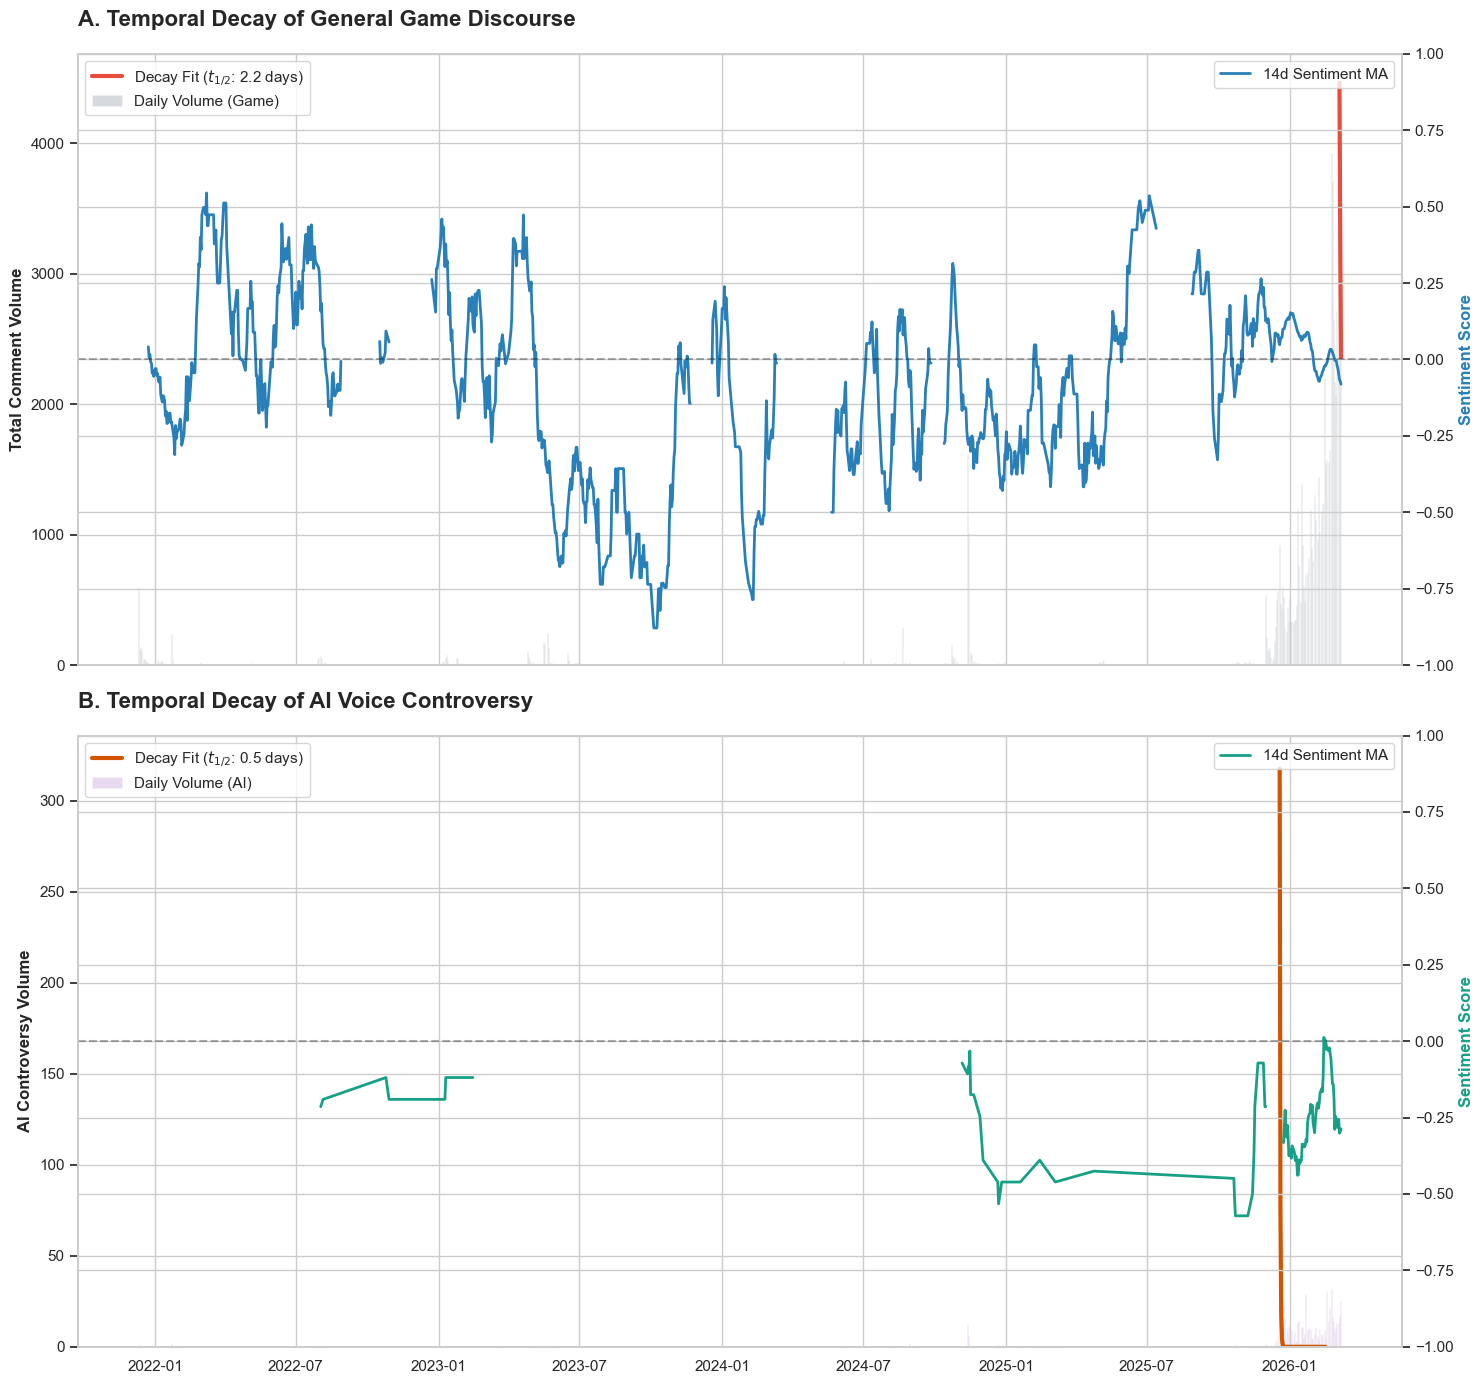

FINAL ANALYSIS RESULTS
GAME DISCOURSE  | Peak: 2026-03-06 | Half-Life: 2.17 days
AI CONTROVERSY  | Peak: 2025-12-19 | Half-Life: 0.48 days


In [7]:
# =============================================================================
# 3. VISUALIZATION
# =============================================================================

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14), sharex=True)

# --- PLOT 1: GENERAL GAME DISCOURSE ---
# Volume Bars
ax1.bar(daily_game['comment_date'], daily_game['volume'], color='#34495E', alpha=0.2, label='Daily Volume (Game)')
# Decay Fit Line
if game_results:
    ax1.plot(game_results['fit_dates'], game_results['fit_values'], color='#E74C3C', linewidth=3, 
             label=f"Decay Fit ($t_{{1/2}}$: {game_results['half_life']:.1f} days)")
# Sentiment Secondary Axis
ax1_s = ax1.twinx()
ax1_s.plot(daily_game['comment_date'], daily_game['sentiment'].rolling(14).mean(), color='#2980B9', linewidth=2, label='14d Sentiment MA')
ax1_s.axhline(0, color='black', linestyle='--', alpha=0.3)
ax1_s.set_ylim(-1, 1)

# Formatting
ax1.set_title("A. Temporal Decay of General Game Discourse", loc='left', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel("Total Comment Volume", fontsize=12, fontweight='bold')
ax1_s.set_ylabel("Sentiment Score", color='#2980B9', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)
ax1_s.legend(loc='upper right', frameon=True)

# --- PLOT 2: AI VOICE CONTROVERSY ---
# Volume Bars
ax2.bar(daily_ai['comment_date'], daily_ai['volume'], color='#8E44AD', alpha=0.2, label='Daily Volume (AI)')
# Decay Fit Line
if ai_results:
    ax2.plot(ai_results['fit_dates'], ai_results['fit_values'], color='#D35400', linewidth=3, 
             label=f"Decay Fit ($t_{{1/2}}$: {ai_results['half_life']:.1f} days)")
# Sentiment Secondary Axis
ax2_s = ax2.twinx()
ax2_s.plot(daily_ai['comment_date'], daily_ai['sentiment'].rolling(14).mean(), color='#16A085', linewidth=2, label='14d Sentiment MA')
ax2_s.axhline(0, color='black', linestyle='--', alpha=0.3)
ax2_s.set_ylim(-1, 1)

# Formatting
ax2.set_title("B. Temporal Decay of AI Voice Controversy", loc='left', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylabel("AI Controversy Volume", fontsize=12, fontweight='bold')
ax2_s.set_ylabel("Sentiment Score", color='#16A085', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', frameon=True)
ax2_s.legend(loc='upper right', frameon=True)

# Global Cleanup
plt.xlabel("Timeline (2024 - 2026)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ArcRaiders_Sentiment_HalfLife_Analysis.png'), dpi=400, bbox_inches='tight')
plt.show()

# Print Statistics for Paper Results Section
print(f"{'='*50}")
print(f"FINAL ANALYSIS RESULTS")
print(f"{'='*50}")
if game_results:
    print(f"GAME DISCOURSE  | Peak: {game_results['peak_date'].date()} | Half-Life: {game_results['half_life']:.2f} days")
if ai_results:
    print(f"AI CONTROVERSY  | Peak: {ai_results['peak_date'].date()} | Half-Life: {ai_results['half_life']:.2f} days")
print(f"{'='*50}")

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Weighted Sentiment Calculation
# We calculate the Weighted Score = sentiment_score * (1 + like_count_log)
# To get the daily average, we use: Sum(Weighted Scores) / Sum(Weights)
df['weighted_sentiment'] = df['sentiment_score'] * (df['like_count_log'] + 1)
df['weight_factor'] = df['like_count_log'] + 1

def get_weighted_daily_stats(df_subset):
    daily = df_subset.groupby(df_subset['comment_date'].dt.date).agg(
        volume=('comment_id', 'count'),
        sum_weighted_sentiment=('weighted_sentiment', 'sum'),
        sum_weights=('weight_factor', 'sum')
    ).reset_index().rename(columns={'index': 'comment_date'})
    
    # Calculate the Weighted Mean Sentiment
    daily['weighted_mean_sentiment'] = daily['sum_weighted_sentiment'] / daily['sum_weights']
    # 7-day rolling average for smoothness
    daily['sentiment_ma'] = daily['weighted_mean_sentiment'].rolling(window=7, min_periods=1).mean()
    return daily

# Process Groups
daily_game = get_weighted_daily_stats(df[df['category'].isin(['Game_Related', 'AI_Voice_Related', 'Business_Model_Related'])])
daily_ai = get_weighted_daily_stats(df[df['category'] == 'AI_Voice_Related'])

# 2. Build Interactive Plotly Figure
fig = make_subplots(rows=2, cols=1, 
                    shared_xaxes=True, 
                    vertical_spacing=0.1,
                    subplot_titles=("A. General Game Discourse (Weighted)", "B. AI Voice Controversy (Weighted)"),
                    specs=[[{"secondary_y": True}], [{"secondary_y": True}]])

# --- SUBPLOT 1: GAME ---
# Volume Bars (Higher Opacity/Less Transparency)
fig.add_trace(go.Bar(x=daily_game['comment_date'], y=daily_game['volume'], 
                     name="Game Volume", marker_color='rgba(44, 62, 80, 0.9)'), # Alpha
              row=1, col=1, secondary_y=False)

# Weighted Sentiment Line
fig.add_trace(go.Scatter(x=daily_game['comment_date'], y=daily_game['sentiment_ma'], 
                         name="Weighted Sentiment (MA)", line=dict(color='#2980B9', width=3)),
              row=1, col=1, secondary_y=True)

# --- SUBPLOT 2: AI VOICE ---
# Volume Bars (Higher Opacity)
fig.add_trace(go.Bar(x=daily_ai['comment_date'], y=daily_ai['volume'], 
                     name="AI Controversy Volume", marker_color='rgba(142, 68, 173, 0.6)'),
              row=2, col=1, secondary_y=False)

# Weighted Sentiment Line
fig.add_trace(go.Scatter(x=daily_ai['comment_date'], y=daily_ai['sentiment_ma'], 
                         name="AI Weighted Sentiment (MA)", line=dict(color='#16A085', width=3)),
              row=2, col=1, secondary_y=True)

# 3. Interactivity & Styling
fig.update_layout(
    height=900,
    title_text="Arc Raiders: Multi-Aspect Sentiment Half-Life Analysis",
    showlegend=True,
    xaxis2_title="Timeline (Click & Drag to Zoom)",
    # Add Range Selector (Buttons for 1m, 6m, etc.)
    xaxis_rangeslider_visible=False,
    xaxis_rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(step="all")
        ])
    )
)

# Set Y-axis constraints for sentiment
fig.update_yaxes(title_text="Volume", secondary_y=False)
fig.update_yaxes(title_text="Weighted Sentiment", range=[-1.1, 1.1], secondary_y=True)

fig.show()

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 160500 entries, 0 to 160499
Data columns (total 27 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   comment_id                       160500 non-null  str           
 1   parent_id                        34930 non-null   str           
 2   parent_text                      34929 non-null   str           
 3   text_preprocessed                160500 non-null  str           
 4   video_title                      160500 non-null  str           
 5   video_context                    151296 non-null  str           
 6   video_id                         160500 non-null  str           
 7   comment_date                     160500 non-null  datetime64[us]
 8   author_hash                      160500 non-null  str           
 9   days_from_genai_announcement     160500 non-null  int64         
 10  days_from_business_model_change  160500 non-null  int64

In [21]:
# =============================================================================
# PATCH: Add Ambivalent → 0 to sentiment_score mapping
# Fixes the 2,933 NaN rows caused by Ambivalent being absent from the original map
# =============================================================================

sentiment_map_full = {'Pos': 1, 'Neu': 0, 'Neg': -1, 'Ambivalent': 0}
df['sentiment_score'] = df['sentiment'].map(sentiment_map_full)

# Recompute weighted sentiment with corrected scores
df['weighted_sentiment'] = df['sentiment_score'] * (df['like_count_log'] + 1)
df['weight_factor'] = df['like_count_log'] + 1

print(f"sentiment_score NaN count after patch: {df['sentiment_score'].isna().sum()}")
print(f"Ambivalent comment count: {(df['sentiment'] == 'Ambivalent').sum()}")

sentiment_score NaN count after patch: 0
Ambivalent comment count: 2933


In [32]:
# =============================================================================
# LOAD RoBERTa Baseline
# =============================================================================

In [37]:
roberta_base_df = pd.read_csv(os.path.join(DATA_DIR, 'roberta_classifications.csv'), low_memory=False)

# RoBERTa columns are already in df — no separate file needed
roberta_base_df['roberta_sentiment'] = roberta_base_df['roberta_sentiment_label'].map({1.0: 'Pos', 0.0: 'Neu', -1.0: 'Neg'})

CONFIDENCE_THRESHOLD = 0.70

# For summary stats, use the full column
roberta_df = roberta_base_df[['comment_id', 'roberta_sentiment', 'roberta_confidence']].copy()
roberta_hc = roberta_df[roberta_df['roberta_confidence'] >= CONFIDENCE_THRESHOLD].copy()

# Comparison df = rows where RoBERTa confidence meets threshold
df_compared = roberta_base_df[roberta_base_df['roberta_confidence'] >= CONFIDENCE_THRESHOLD].copy()

print(f"Total RoBERTa labeled rows:        {roberta_df['roberta_confidence'].notna().sum():,}")
print(f"High-confidence (≥0.70):           {len(roberta_hc):,} ({100*len(roberta_hc)/roberta_df['roberta_confidence'].notna().sum():.1f}%)")
print(f"Rows for comparative analysis:     {len(df_compared):,}")

Total RoBERTa labeled rows:        189,726
High-confidence (≥0.70):           118,403 (62.4%)
Rows for comparative analysis:     118,403


---

## Section 4.1 — Dataset Statistics

In [ ]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total labeled comments:  {len(df):,}")
print(f"Date range:              {df['comment_date'].min().date()} → {df['comment_date'].max().date()}")
print(f"Unique videos:           {df['video_id'].nunique():,}")
print(f"Unique commenters:       {df['author_hash'].nunique():,}")

print("\n--- Sentiment Distribution ---")
sent_counts = df['sentiment'].value_counts()
sent_pct    = df['sentiment'].value_counts(normalize=True) * 100
sent_table  = pd.DataFrame({'Count': sent_counts, 'Pct (%)': sent_pct.round(2)})
print(sent_table.to_string())

print("\n--- Category Distribution ---")
cat_counts = df['category'].value_counts()
cat_pct    = df['category'].value_counts(normalize=True) * 100
cat_table  = pd.DataFrame({'Count': cat_counts, 'Pct (%)': cat_pct.round(2)})
print(cat_table.to_string())

print("\n--- Confidence Distribution ---")
print(df['confidence'].describe().round(3).to_string())
low_conf_n = (df['confidence'] < 0.70).sum()
print(f"\nLLM labels with confidence < 0.70: {low_conf_n:,} ({100*low_conf_n/len(df):.1f}%)")

DATASET OVERVIEW
Total labeled comments:  160,500
Date range:              2021-12-10 → 2026-03-08
Unique videos:           905
Unique commenters:       95,733

--- Sentiment Distribution ---
            Count  Pct (%)
sentiment                 
Pos         67299    41.93
Neg         64645    40.28
Neu         25623    15.96
Ambivalent   2933     1.83

--- Category Distribution ---
                         Count  Pct (%)
category                               
Game_Related            117244    73.05
Others                   38505    23.99
Business_Model_Related    2977     1.85
AI_Voice_Related          1774     1.11

--- Confidence Distribution ---
count    160500.000
mean          0.855
std           0.067
min           0.200
25%           0.800
50%           0.850
75%           0.900
max           1.000

LLM labels with confidence < 0.70: 2,770 (1.7%)


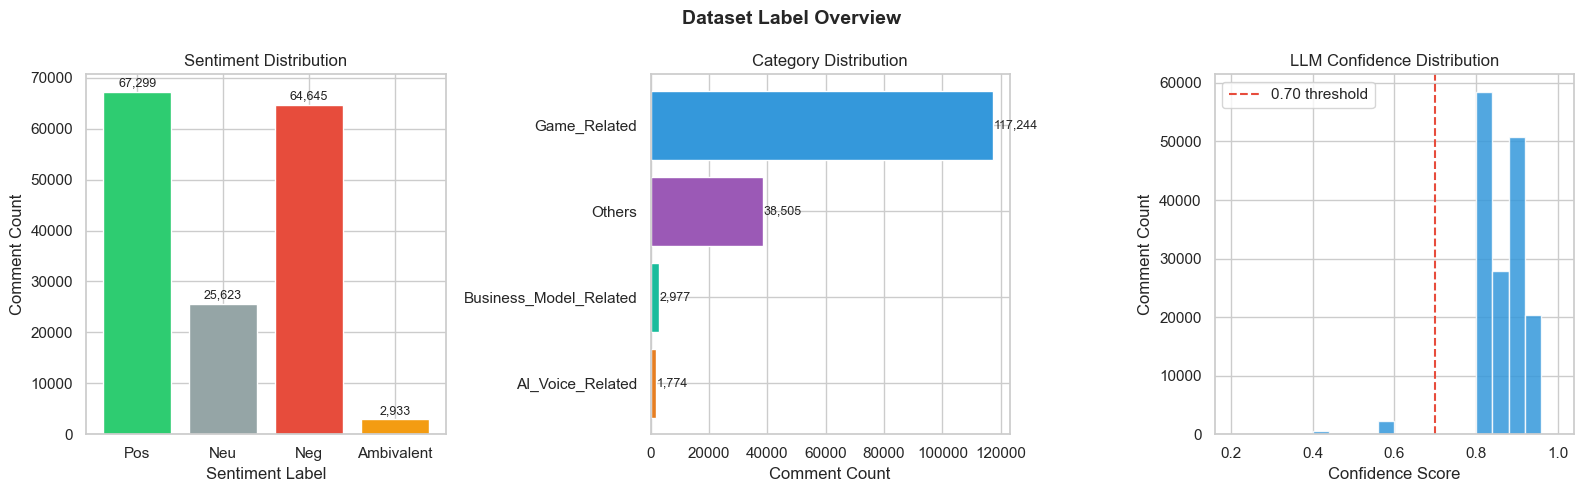

Saved → figures/05_dataset_label_overview.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dataset Label Overview", fontsize=14, fontweight='bold')

SENT_ORDER = ['Pos', 'Neu', 'Neg', 'Ambivalent']
SENT_COLORS = {'Pos': '#2ecc71', 'Neu': '#95a5a6', 'Neg': '#e74c3c', 'Ambivalent': '#f39c12'}
CAT_COLORS  = ['#3498db', '#9b59b6', '#1abc9c', '#e67e22']

# --- Sentiment bar ---
ax = axes[0]
order = [s for s in SENT_ORDER if s in sent_counts.index]
colors = [SENT_COLORS[s] for s in order]
ax.bar(order, sent_counts[order], color=colors, edgecolor='white')
for bar, val in zip(ax.patches, sent_counts[order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Sentiment Distribution')
ax.set_ylabel('Comment Count')
ax.set_xlabel('Sentiment Label')

# --- Category bar ---
ax = axes[1]
cats = cat_counts.index.tolist()
ax.barh(cats, cat_counts[cats], color=CAT_COLORS, edgecolor='white')
for bar, val in zip(ax.patches, cat_counts[cats]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Category Distribution')
ax.set_xlabel('Comment Count')
ax.invert_yaxis()

# --- LLM Confidence histogram ---
ax = axes[2]
ax.hist(df['confidence'], bins=20, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(0.70, color='#e74c3c', linewidth=1.5, linestyle='--', label='0.70 threshold')
ax.set_title('LLM Confidence Distribution')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Comment Count')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_dataset_label_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/05_dataset_label_overview.png")

---
## Section 4.2 — Event Detection

In [ ]:
# Spike days already flagged via z-score in your wrangling notebook
spike_days = df[df['is_spike'] == True].groupby(
    df['comment_date'].dt.date
).agg(
    volume=('comment_id', 'count'),
    z_score=('z_score', 'mean')
).reset_index().rename(columns={'comment_date': 'date'})

spike_days = spike_days.sort_values('date').reset_index(drop=True)

# Cluster spikes that are within 3 days of each other into one event
CLUSTER_GAP_DAYS = 3
spike_days['date'] = pd.to_datetime(spike_days['date'])

clusters = []
current_cluster = [spike_days.iloc[0]]
for i in range(1, len(spike_days)):
    row = spike_days.iloc[i]
    if (row['date'] - current_cluster[-1]['date']).days <= CLUSTER_GAP_DAYS:
        current_cluster.append(row)
    else:
        clusters.append(current_cluster)
        current_cluster = [row]
clusters.append(current_cluster)

# Pick the peak day within each cluster as the event anchor
events_detected = []
for cluster in clusters:
    cluster_df = pd.DataFrame(cluster)
    peak_row = cluster_df.loc[cluster_df['volume'].idxmax()]
    events_detected.append({
        'event_date': peak_row['date'].date(),
        'peak_volume': int(peak_row['volume']),
        'mean_z_score': round(cluster_df['z_score'].mean(), 2),
        'cluster_days': len(cluster)
    })

events_df = pd.DataFrame(events_detected).sort_values('peak_volume', ascending=False)

print(f"Total spike days detected:   {len(spike_days)}")
print(f"Clustered into events:       {len(events_df)}")
print("\nTop events by volume (fill in 'event_label' column manually below):")
print(events_df.to_string(index=False))

Total spike days detected:   57
Clustered into events:       33

Top events by volume (fill in 'event_label' column manually below):
event_date  peak_volume  mean_z_score  cluster_days
2026-02-24         5115          3.16             3
2026-02-15         3051          2.80             1
2026-01-16         1778          3.86             2
2024-11-12         1736          5.20             1
2026-01-11         1469          2.97             1
2025-11-30          677          4.08             3
2024-08-20          340          5.26             1
2022-01-22          272          3.93             2
2023-05-21          253          3.12             1
2024-10-23          228          4.51             2
2023-05-16          200          3.79             2
2025-12-05          141          3.69             1
2023-04-25          117          5.21             1
2023-01-10           94          4.24             5
2022-07-30           68          3.99             4
2024-07-10           63          5.

In [62]:
# Known events — used directly as anchors regardless of volume spike
KNOWN_EVENTS = {
    '2021-12-09': 'Game Announcement',
    '2023-05-01': 'PvPvE Design Pivot',
    '2025-06-06': 'Business Model Change',
    '2025-10-30': 'Official Game Launch',
    '2025-11-12': 'AI Voice Acting News',
    '2025-11-13': 'North Line Update',
    '2026-03-15': 'AI Voice Replacement',
}

# Ensure datetime once
events_df['event_date'] = pd.to_datetime(events_df['event_date'])

confirmed_events = pd.DataFrame([
    {'event_date': pd.to_datetime(date), 'event_label': label}
    for date, label in KNOWN_EVENTS.items()
])

def get_peak_after(d):
    # Filter to only future (or same-day) events
    df = events_df[events_df['event_date'] >= d]

    if df.empty:
        return None

    # Find closest future date
    time_deltas = df['event_date'] - d
    idx = time_deltas.idxmin()

    # Enforce 30-day window
    if time_deltas.loc[idx].days <= 30:
        return df.loc[idx, 'peak_volume']

    return None

# Apply function
confirmed_events['peak_volume'] = confirmed_events['event_date'].apply(get_peak_after)

print(confirmed_events[['event_date', 'event_label', 'peak_volume']].to_string(index=False))

event_date           event_label  peak_volume
2021-12-09     Game Announcement          NaN
2023-05-01    PvPvE Design Pivot        200.0
2025-06-06 Business Model Change          NaN
2025-10-30  Official Game Launch          NaN
2025-11-12  AI Voice Acting News        677.0
2025-11-13     North Line Update        677.0
2026-03-15  AI Voice Replacement          NaN


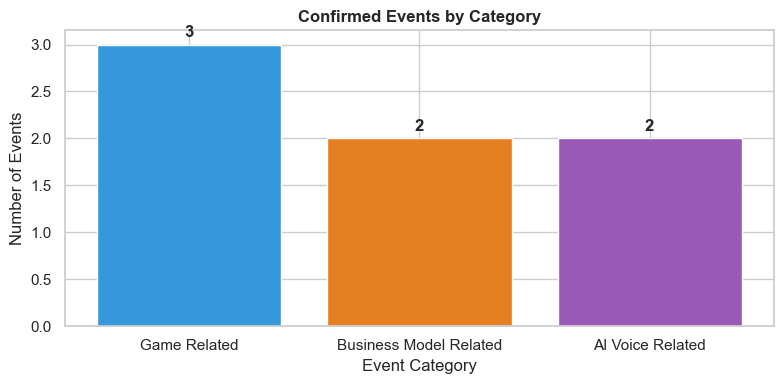

Saved → figures/06_event_taxonomy.png


In [65]:
# Map specific event labels to broader categories for the taxonomy chart
EVENT_CATEGORIES = {
    'Game Announcement':     'Game_Related',
    'PvPvE Design Pivot':    'Business_Model_Related',
    'Business Model Change': 'Business_Model_Related',
    'Official Game Launch':  'Game_Related',
    'AI Voice Acting News':  'AI_Voice_Related',
    'North Line Update':     'Game_Related',
    'AI Voice Replacement':  'AI_Voice_Related',
}

confirmed_events['category'] = confirmed_events['event_label'].map(EVENT_CATEGORIES)

# Chart by category
label_counts = confirmed_events['category'].value_counts()

TAXONOMY_COLORS = {
    'Game_Related':            '#3498db',
    'Business_Model_Related':  '#e67e22',
    'AI_Voice_Related':        '#9b59b6',
}

fig, ax = plt.subplots(figsize=(8, 4))
colors = [TAXONOMY_COLORS.get(l, '#bdc3c7') for l in label_counts.index]
ax.bar([l.replace('_', ' ') for l in label_counts.index], label_counts.values,
       color=colors, edgecolor='white')
ax.set_title('Confirmed Events by Category', fontweight='bold')
ax.set_ylabel('Number of Events')
ax.set_xlabel('Event Category')
for bar, val in zip(ax.patches, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_event_taxonomy.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/06_event_taxonomy.png")

---
## Section 4.3 — Temporal Sentiment Windows

In [ ]:
# =============================================================================
# Pre-event: 7 days before | Event: ±2 days | Post-event: 7 days after
# LLM labels used as ground truth throughout
# =============================================================================
PRE_DAYS     = 7
POST_DAYS    = 7
EVENT_WINDOW = 2  # ±2 days around event anchor

def classify_window(comment_date, event_date):
    delta = (comment_date - event_date).days
    if -PRE_DAYS <= delta < -EVENT_WINDOW:
        return 'Pre-Event'
    elif -EVENT_WINDOW <= delta <= EVENT_WINDOW:
        return 'Event'
    elif EVENT_WINDOW < delta <= POST_DAYS:
        return 'Post-Event'
    return None

window_records = []
for _, event_row in confirmed_events.iterrows():
    edate    = event_row['event_date']
    elabel   = event_row['event_label']
    ecategory = event_row['category']

    window_start = edate - pd.Timedelta(days=PRE_DAYS)
    window_end   = edate + pd.Timedelta(days=POST_DAYS)

    mask = (df['comment_date'] >= window_start) & (df['comment_date'] <= window_end)
    subset = df[mask].copy()
    subset['window']         = subset['comment_date'].apply(lambda d: classify_window(d, edate))
    subset = subset[subset['window'].notna()]
    subset['event_label']    = elabel
    subset['event_date']     = edate
    subset['event_category'] = ecategory
    window_records.append(subset)

if window_records:
    windows_df = pd.concat(window_records, ignore_index=True)
    print(f"Total windowed comment rows: {len(windows_df):,}")
    print(windows_df.groupby(['event_category', 'event_label', 'window'])['sentiment_score']
          .agg(['count', 'mean']).round(3))
else:
    print("⚠️  No confirmed events yet.")
    windows_df = pd.DataFrame()

Total windowed comment rows: 5,473
                                                         count   mean
event_category         event_label           window                  
AI_Voice_Related       AI Voice Acting News  Event         122  0.090
                                             Post-Event     55  0.255
                                             Pre-Event     118 -0.042
                       AI Voice Replacement  Pre-Event    2753  0.035
Business_Model_Related Business Model Change Event          11  0.455
                                             Post-Event      2  0.500
                                             Pre-Event      32  0.281
                       PvPvE Design Pivot    Event         104 -0.250
                                             Post-Event     26 -0.231
                                             Pre-Event     291 -0.052
Game_Related           Game Announcement     Event         951  0.210
                                             Post-Event

In [67]:
# Aggregate: mean sentiment score and sentiment ratio per window per event

if not windows_df.empty:
    WINDOW_ORDER = ['Pre-Event', 'Event', 'Post-Event']

    window_agg = windows_df.groupby(['event_label', 'window']).agg(
        comment_count=('comment_id', 'count'),
        mean_sentiment=('sentiment_score', 'mean'),
        pct_pos=('sentiment', lambda x: (x == 'Pos').mean() * 100),
        pct_neg=('sentiment', lambda x: (x == 'Neg').mean() * 100),
        pct_neu=('sentiment', lambda x: (x == 'Neu').mean() * 100),
    ).reset_index()
    window_agg['window'] = pd.Categorical(window_agg['window'], categories=WINDOW_ORDER, ordered=True)
    window_agg = window_agg.sort_values(['event_label', 'window'])

    print("Sentiment by Event × Window:")
    print(window_agg.to_string(index=False))

Sentiment by Event × Window:
          event_label     window  comment_count  mean_sentiment   pct_pos   pct_neg   pct_neu
 AI Voice Acting News  Pre-Event            118       -0.042373 37.288136 41.525424 16.101695
 AI Voice Acting News      Event            122        0.090164 42.622951 33.606557 18.852459
 AI Voice Acting News Post-Event             55        0.254545 52.727273 27.272727 18.181818
 AI Voice Replacement  Pre-Event           2753        0.035234 41.699964 38.176535 18.888485
Business Model Change  Pre-Event             32        0.281250 53.125000 25.000000 15.625000
Business Model Change      Event             11        0.454545 63.636364 18.181818 18.181818
Business Model Change Post-Event              2        0.500000 50.000000  0.000000 50.000000
    Game Announcement      Event            951        0.210305 48.790747 27.760252 18.191377
    Game Announcement Post-Event            504        0.061508 42.658730 36.507937 14.285714
    North Line Update  Pre-Even

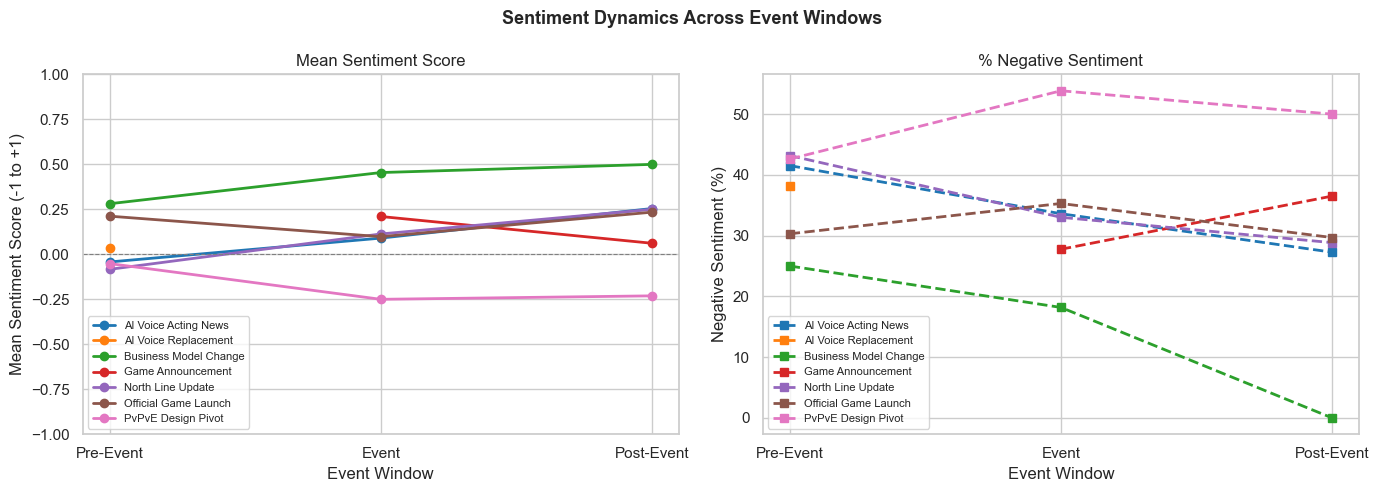

Saved → figures/07_temporal_sentiment_windows.png


In [68]:
# Publication-ready figure: mean sentiment across windows, one line per event type

if not windows_df.empty:
    event_labels = window_agg['event_label'].unique()
    palette = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Sentiment Dynamics Across Event Windows', fontsize=13, fontweight='bold')

    # Left: mean sentiment score
    ax = axes[0]
    for i, label in enumerate(event_labels):
        subset = window_agg[window_agg['event_label'] == label].sort_values('window')
        ax.plot(subset['window'].astype(str), subset['mean_sentiment'],
                marker='o', label=label, color=palette[i], linewidth=2)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title('Mean Sentiment Score')
    ax.set_ylabel('Mean Sentiment Score (-1 to +1)')
    ax.set_xlabel('Event Window')
    ax.legend(fontsize=8)
    ax.set_ylim(-1, 1)

    # Right: % Negative sentiment
    ax = axes[1]
    for i, label in enumerate(event_labels):
        subset = window_agg[window_agg['event_label'] == label].sort_values('window')
        ax.plot(subset['window'].astype(str), subset['pct_neg'],
                marker='s', label=label, color=palette[i], linewidth=2, linestyle='--')
    ax.set_title('% Negative Sentiment')
    ax.set_ylabel('Negative Sentiment (%)')
    ax.set_xlabel('Event Window')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '07_temporal_sentiment_windows.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → figures/07_temporal_sentiment_windows.png")

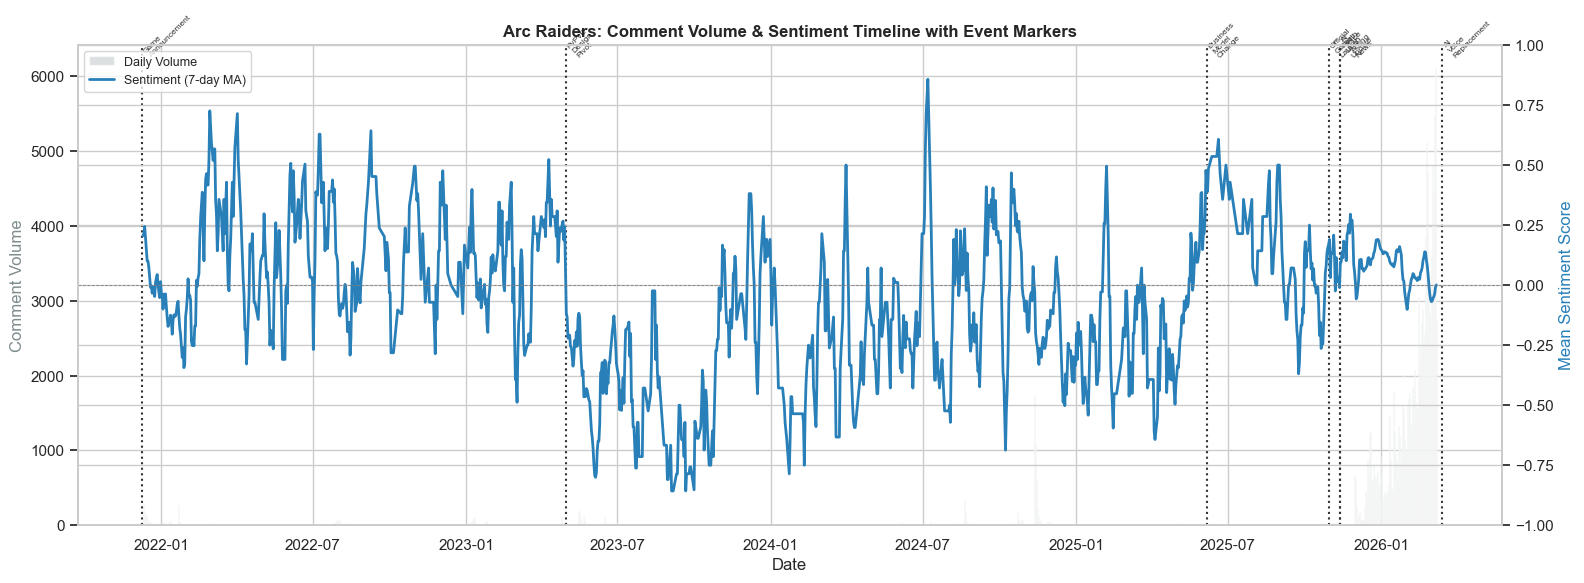

Saved → figures/08_full_timeline_with_events.png


In [69]:
# Full timeline figure: daily sentiment + event markers

daily_all = df.groupby(df['comment_date'].dt.date).agg(
    volume=('comment_id', 'count'),
    mean_sentiment=('sentiment_score', 'mean')
).reset_index().rename(columns={'comment_date': 'date'})
daily_all['date'] = pd.to_datetime(daily_all['date'])
daily_all['sentiment_ma7'] = daily_all['mean_sentiment'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.bar(daily_all['date'], daily_all['volume'],
        color='#bdc3c7', alpha=0.5, label='Daily Volume', width=1)
ax2.plot(daily_all['date'], daily_all['sentiment_ma7'],
         color='#2980b9', linewidth=2, label='Sentiment (7-day MA)')
ax2.axhline(0, color='grey', linewidth=0.6, linestyle='--')

# Event markers
if not confirmed_events.empty:
    for _, ev in confirmed_events.iterrows():
        color = TAXONOMY_COLORS.get(ev['event_label'], '#333')
        ax1.axvline(ev['event_date'], color=color, linewidth=1.5, linestyle=':')
        ax1.text(ev['event_date'], daily_all['volume'].max() * 1.02,
                 ev['event_label'].replace(' ', '\n'),
                 fontsize=6, color=color, rotation=45, ha='left', va='bottom')

ax1.set_xlabel('Date')
ax1.set_ylabel('Comment Volume', color='#7f8c8d')
ax2.set_ylabel('Mean Sentiment Score', color='#2980b9')
ax2.set_ylim(-1, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Arc Raiders: Comment Volume & Sentiment Timeline with Event Markers',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '08_full_timeline_with_events.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/08_full_timeline_with_events.png")

---
## Section 4.4 — Per-Category Sentiment Breakdown

In [ ]:
CAT_ORDER  = ['Game_Related', 'AI_Voice_Related', 'Business_Model_Related', 'Others']
SENT_ORDER_FULL = ['Pos', 'Neu', 'Neg', 'Ambivalent']

cat_sent = df.groupby(['category', 'sentiment']).size().unstack(fill_value=0)
# Ensure all sentiment columns present
for col in SENT_ORDER_FULL:
    if col not in cat_sent.columns:
        cat_sent[col] = 0
cat_sent = cat_sent[SENT_ORDER_FULL].loc[CAT_ORDER]

cat_sent_pct = cat_sent.div(cat_sent.sum(axis=1), axis=0) * 100

print("Sentiment % by Category:")
print(cat_sent_pct.round(2).to_string())

print("\nMean Sentiment Score by Category:")
print(df.groupby('category')['sentiment_score'].agg(['mean', 'std', 'count']).round(3).loc[CAT_ORDER].to_string())

Sentiment % by Category:
sentiment                 Pos    Neu    Neg  Ambivalent
category                                               
Game_Related            41.61  13.43  42.90        2.05
AI_Voice_Related        23.90  16.97  54.74        4.40
Business_Model_Related  17.94   9.17  70.57        2.32
Others                  45.58  24.15  29.28        0.99

Mean Sentiment Score by Category:
                         mean    std   count
category                                    
Game_Related           -0.013  0.919  117244
AI_Voice_Related       -0.308  0.832    1774
Business_Model_Related -0.526  0.780    2977
Others                  0.163  0.850   38505


/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_34308/2570750948.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace('_', '\n') for c in CAT_ORDER], fontsize=9)


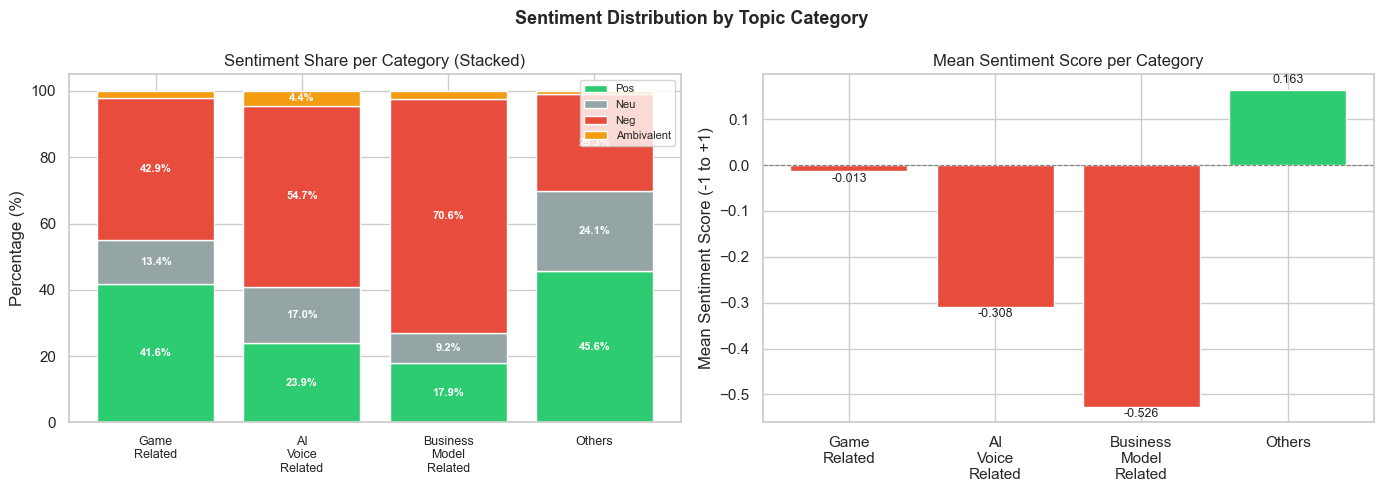

Saved → figures/09_category_sentiment_breakdown.png


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Distribution by Topic Category', fontsize=13, fontweight='bold')

# Left: stacked bar (% sentiment per category)
ax = axes[0]
bottom = np.zeros(len(CAT_ORDER))
bar_colors = [SENT_COLORS[s] for s in SENT_ORDER_FULL]
for sent, color in zip(SENT_ORDER_FULL, bar_colors):
    vals = cat_sent_pct[sent].values
    bars = ax.bar(CAT_ORDER, vals, bottom=bottom, label=sent, color=color, edgecolor='white')
    for bar, v, b in zip(bars, vals, bottom):
        if v > 4:
            ax.text(bar.get_x() + bar.get_width()/2, b + v/2,
                    f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_title('Sentiment Share per Category (Stacked)')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels([c.replace('_', '\n') for c in CAT_ORDER], fontsize=9)
ax.legend(loc='upper right', fontsize=8)

# Right: mean sentiment score per category
ax = axes[1]
mean_scores = df.groupby('category')['sentiment_score'].mean().loc[CAT_ORDER]
bar_clrs = ['#2ecc71' if v >= 0 else '#e74c3c' for v in mean_scores.values]
ax.bar([c.replace('_', '\n') for c in CAT_ORDER], mean_scores.values,
       color=bar_clrs, edgecolor='white')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Mean Sentiment Score per Category')
ax.set_ylabel('Mean Sentiment Score (-1 to +1)')
for bar, val in zip(ax.patches, mean_scores.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.01 if val >= 0 else -0.03),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '09_category_sentiment_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/09_category_sentiment_breakdown.png")

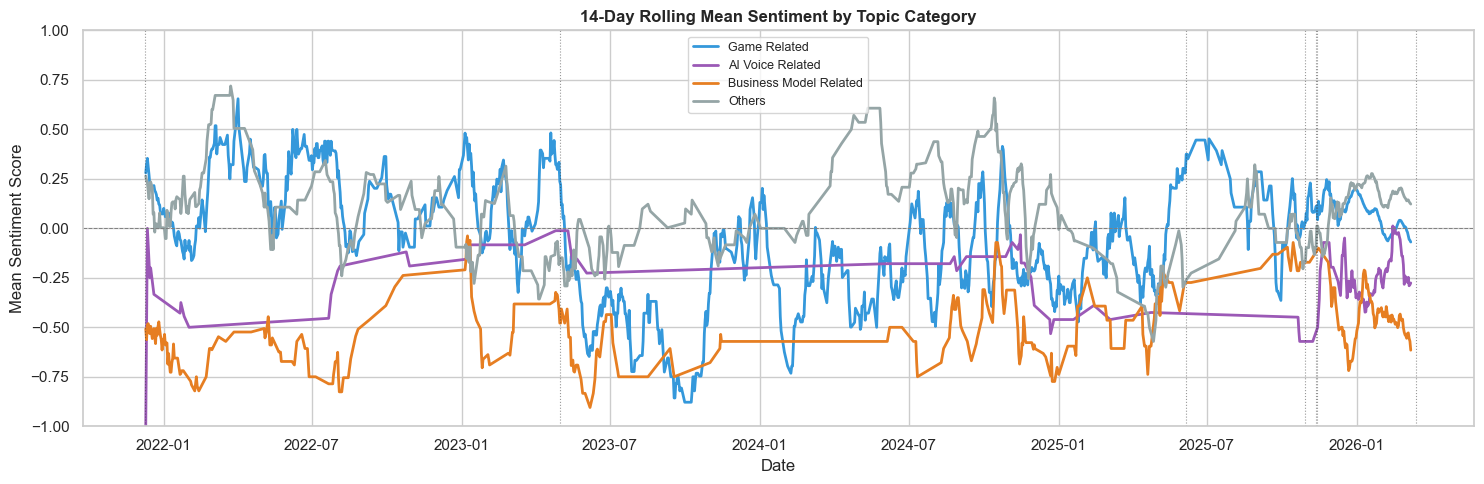

Saved → figures/10_category_sentiment_timeseries.png


In [72]:
# Category sentiment over time — shows AI/Business trending negative
fig, ax = plt.subplots(figsize=(15, 5))

category_colors = {
    'Game_Related':            '#3498db',
    'AI_Voice_Related':        '#9b59b6',
    'Business_Model_Related':  '#e67e22',
    'Others':                  '#95a5a6'
}

for cat in CAT_ORDER:
    subset = df[df['category'] == cat].copy()
    daily_cat = subset.groupby(subset['comment_date'].dt.date)['sentiment_score'].mean().reset_index()
    daily_cat.columns = ['date', 'sentiment_ma']
    daily_cat['date'] = pd.to_datetime(daily_cat['date'])
    daily_cat = daily_cat.sort_values('date')
    daily_cat['sentiment_ma'] = daily_cat['sentiment_ma'].rolling(14, min_periods=1).mean()
    ax.plot(daily_cat['date'], daily_cat['sentiment_ma'],
            label=cat.replace('_', ' '), color=category_colors[cat], linewidth=2)

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')

# Add event markers if available
if not confirmed_events.empty:
    for _, ev in confirmed_events.iterrows():
        ax.axvline(ev['event_date'], color='#333', linewidth=0.8, linestyle=':', alpha=0.5)

ax.set_title('14-Day Rolling Mean Sentiment by Topic Category', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sentiment Score')
ax.set_ylim(-1, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '10_category_sentiment_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/10_category_sentiment_timeseries.png")

---
## Section 4.6 — RoBERTa vs LLM Agreement

In [73]:
# =============================================================================
# 4.6 RoBERTa vs LLM Agreement
# LLM labels = ground truth | High-confidence RoBERTa (≥0.70) = comparison
# Ambivalent excluded from agreement computation (mapped Neu for scoring already)
# =============================================================================

def gwet_ac1(rater1, rater2):
    """
    Compute Gwet's AC1 for two lists of categorical ratings.
    Paradox-resistant alternative to Cohen's Kappa.
    """
    assert len(rater1) == len(rater2), "Rater arrays must be same length"
    n = len(rater1)
    categories = sorted(set(rater1) | set(rater2))
    k = len(categories)

    # Observed agreement
    pa = np.mean([r1 == r2 for r1, r2 in zip(rater1, rater2)])

    # Gwet's chance agreement (uses average marginal proportions)
    pe = 0
    for cat in categories:
        pi_k = ((np.sum(np.array(rater1) == cat) + np.sum(np.array(rater2) == cat))
                / (2 * n))
        pe += pi_k * (1 - pi_k)
    pe = pe / (k - 1)

    ac1 = (pa - pe) / (1 - pe)
    return round(pa, 4), round(pe, 4), round(ac1, 4)

In [86]:
roberta_raw = pd.read_csv(os.path.join(DATA_DIR, 'roberta_classifications.csv'), 
                           low_memory=False,
                           usecols=['comment_id', 'roberta_sentiment_label', 'roberta_confidence'])

# Drop the 179K duplicate/unlabeled rows
roberta_df = roberta_raw.dropna(subset=['roberta_confidence']).copy()
roberta_df['roberta_sentiment'] = roberta_df['roberta_sentiment_label'].map({1.0: 'Pos', 0.0: 'Neu', -1.0: 'Neg'})

# High confidence subset
CONFIDENCE_THRESHOLD = 0.70
df_compared = roberta_df[roberta_df['roberta_confidence'] >= CONFIDENCE_THRESHOLD].copy()

print(f"Total RoBERTa labeled rows:        {len(roberta_df):,}")
print(f"High-confidence (≥0.70):           {len(df_compared):,}")
print(f"Overlap with df:                   {len(set(df['comment_id']) & set(df_compared['comment_id'])):,}")

Total RoBERTa labeled rows:        189,726
High-confidence (≥0.70):           118,403
Overlap with df:                   6,744


In [87]:
merged = df.merge(
    df_compared,
    on='comment_id',
    how='outer',
    indicator=True
)

print(merged['_merge'].value_counts())

# See examples not matching
merged[merged['_merge'] != 'both'].head(10)

_merge
left_only     153756
right_only    111659
both            6744
Name: count, dtype: int64


,comment_id,parent_id,parent_text,text_preprocessed,video_title,video_context,video_id,comment_date,author_hash,days_from_genai_announcement,...,weighted_sentiment,weight_factor,roberta_sentiment_x,roberta_confidence_x,roberta_sentiment_y,roberta_confidence_y,roberta_sentiment_label,roberta_confidence,roberta_sentiment,_merge
0,Ugw--1DMoiezkof6bq54AaABAg,NaN,NaN,This is just another Apex legends,Tee Grizzley Plays Arc Raiders For The First T...,TEE GRIZZLEY Playing Arc Raiders Let's Hit 4K ...,V0qLRMt1mg0,2026-02-07 22:44:42,f1f7a29f5ca7d9bbb72c88f0e33e00e930056bf0f4ff86...,633.0,...,-1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,Ugw--6vRxLLYVy8vqEp4AaABAg,NaN,NaN,Hey I really thought I enjoyed ur content salt...,There&#39;s a Glitch in ARC Raiders.,so many blueprints #arcraiders #sallyisadogsho...,VeLjFwhkh-s,2026-01-23 02:47:42,85ed18e26a3f17d331a8ba96afa539a8f2930e0ef45f54...,618.0,...,-1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2,Ugw--HYX4cEacgE8zfV4AaABAg,NaN,NaN,When will we get a hullcracker blueprint?,Matriarch Reactor Farming is Broken Right Now ...,"In this Arc Raiders guide, we show you how to ...",Jx-S32eJwEw,2026-02-19 15:37:38,0d7dc21e70795f73f43de7aaf7d031ed3bee5ecfdfec27...,645.0,...,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
3,Ugw--YKi5CJCR3h905R4AaABAg,NaN,NaN,if there is no collective goal; chaos will reign,ARC RAIDERS PLAYERS ARE TOO FRIENDLY?! #gaming...,The devs behind Arc Raiders were actually real...,8xshAJSxeqQ,2026-02-27 06:32:58,ed1b443add5460fcbababf51e572cd0e535de11d83fbae...,653.0,...,-3.772589,3.772589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
4,Ugw--YKi5CJCR3h905R4AaABAg.ATiai__2MaAAU1_iHLNYpR,Ugw--YKi5CJCR3h905R4AaABAg,if there is no collective goal; chaos will reign,I play with a collective goal in mind of destr...,ARC RAIDERS PLAYERS ARE TOO FRIENDLY?! #gaming...,The devs behind Arc Raiders were actually real...,8xshAJSxeqQ,2026-03-07 00:49:00,92383fc9a50725971a68e3a0c9591a2182cc9387b371e8...,661.0,...,1.693147,1.693147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
6,Ugw--wWAB3wH-MqIuxV4AaABAg,NaN,NaN,It's all mixed there is no aggression/karma ba...,ARC Raiders has been LYING to us...,Drop a LIKE + SUBSCRIBE if you enjoyed :) JOIN...,Zp8qiI1kwVs,2026-03-03 10:55:06,3f969d9973ce0a7444e1a24fbd960e9a37767f2dffc782...,657.0,...,-1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
7,Ugw--xjeiWGMS_uRBFN4AaABAg,NaN,NaN,Bird City! Bird City! 🐦 🕊️,Just When I Thought I Had It All | Arc Raiders,arcraiders #burntpeanut.,_qq8uWiblvw,2026-01-30 01:10:47,25c687571893f4d051062280dd185a352275eef0e2477d...,625.0,...,4.912023,4.912023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
8,Ugw-0C3bMhTMH3DOjgt4AaABAg,NaN,NaN,stop using unfriendly so much. stop using rat ...,ARC Raiders devs really said this 😭,"arc raiders, arc raiders gameplay, arc raiders...",5VCxW5OKWMA,2026-03-01 18:57:37,515e58111d60e16a34f5a8e1eb57e76d49d435c5420427...,655.0,...,-1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
9,Ugw-0C3bMhTMH3DOjgt4AaABAg.ATp4XHoPh2RATp4eKIAYhP,Ugw-0C3bMhTMH3DOjgt4AaABAg,stop using unfriendly so much. stop using rat ...,You’re not “supposed” to do anything except pl...,ARC Raiders devs really said this 😭,"arc raiders, arc raiders gameplay, arc raiders...",5VCxW5OKWMA,2026-03-01 18:58:43,072172a6401a85660ec9f6f51625166748fa7d1b97dc21...,655.0,...,-1.693147,1.693147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
10,Ugw-0C3bMhTMH3DOjgt4AaABAg.ATp4XHoPh2RATq3W_OJXef,Ugw-0C3bMhTMH3DOjgt4AaABAg,stop using unfriendly so much. stop using rat ...,Your main goal is to bring resources. Resource...,ARC Raiders devs really said this 😭,"arc raiders, arc raiders gameplay, arc raiders...",5VCxW5OKWMA,2026-03-02 04:08:01,1ea6dfd9f9a7d381631a4bdcaa046be4b09c111d9aa893...,656.0,...,0.000000,1.693147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [ ]:
# Merge LLM ground truth with high-confidence RoBERTa on comment_id
agree_df = df[['comment_id', 'sentiment', 'category']].merge(
    roberta_df[roberta_df['roberta_confidence'] >= CONFIDENCE_THRESHOLD][
        ['comment_id', 'roberta_sentiment', 'roberta_confidence']
    ],
    on='comment_id',
    how='inner'
)
agree_df = agree_df[agree_df['sentiment'] != 'Ambivalent'].copy()
print(f"N available for agreement analysis: {len(agree_df):,}")

# Exclude Ambivalent from LLM side (RoBERTa has no Ambivalent class)
agree_df = agree_df[agree_df['sentiment'] != 'Ambivalent'].copy()

llm_labels     = agree_df['sentiment'].tolist()
roberta_labels = agree_df['roberta_sentiment'].tolist()

print(f"N available for agreement analysis: {len(agree_df):,}")

N available for agreement analysis: 6,533


In [76]:
# Only rows where BOTH labels are available and RoBERTa confidence ≥ 0.70
# Exclude Ambivalent from agreement (too few, and it's mapped to Neu in scoring)
llm_labels    = agree_df['sentiment'].tolist()          # LLM = ground truth
roberta_labels = agree_df['roberta_sentiment'].tolist() # High-conf RoBERTa

pa, pe, ac1 = gwet_ac1(llm_labels, roberta_labels)

print("=" * 50)
print("SENTIMENT AGREEMENT: RoBERTa (HC) vs LLM")
print("=" * 50)
print(f"N (high-confidence pairs):  {len(agree_df):,}")
print(f"Percent Agreement:          {pa:.3f}")
print(f"Gwet's AC1:                 {ac1:.3f}  (Paradox Resistant)")
print(f"Cohen's Kappa:              {cohen_kappa_score(llm_labels, roberta_labels):.3f}")
print()
print("--- Classification Report (LLM as reference) ---")
print(classification_report(llm_labels, roberta_labels, zero_division=0))

SENTIMENT AGREEMENT: RoBERTa (HC) vs LLM
N (high-confidence pairs):  6,533
Percent Agreement:          0.863
Gwet's AC1:                 0.800  (Paradox Resistant)
Cohen's Kappa:              0.783

--- Classification Report (LLM as reference) ---
              precision    recall  f1-score   support

         Neg       0.93      0.86      0.89      2812
         Neu       0.66      0.80      0.72      1056
         Pos       0.90      0.89      0.89      2665

    accuracy                           0.86      6533
   macro avg       0.83      0.85      0.84      6533
weighted avg       0.87      0.86      0.87      6533



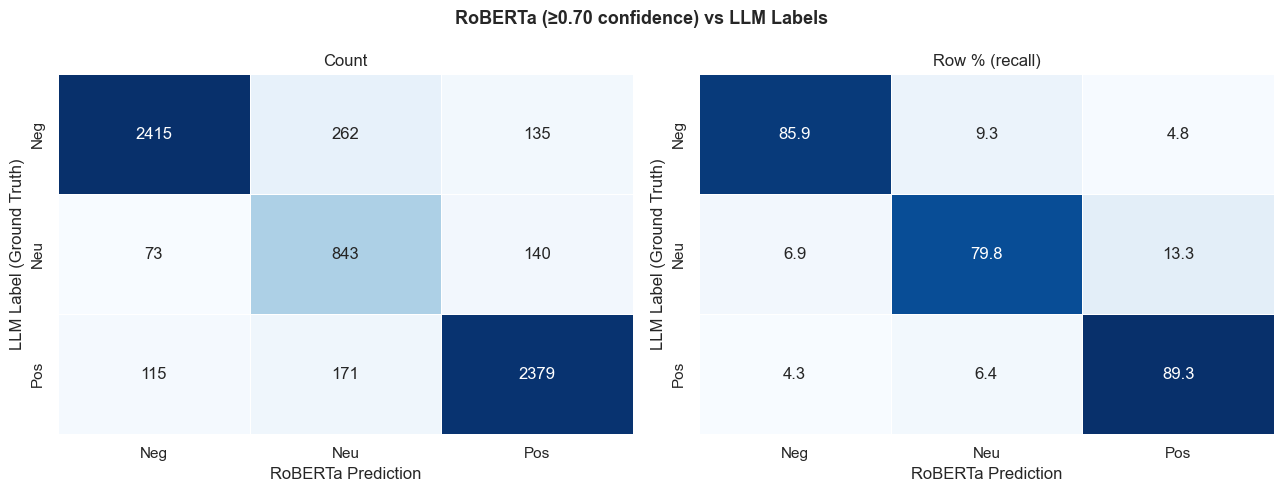

Saved → figures/11_roberta_vs_llm_confusion.png


In [77]:
# Confusion matrix: RoBERTa predictions vs LLM ground truth
label_set = sorted(set(llm_labels) | set(roberta_labels))
cm = confusion_matrix(llm_labels, roberta_labels, labels=label_set)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RoBERTa (≥0.70 confidence) vs LLM Labels', fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ['d', '.1f'],
    ['Count', 'Row % (recall)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=label_set, yticklabels=label_set, ax=ax,
                linewidths=0.5, cbar=False)
    ax.set_xlabel('RoBERTa Prediction')
    ax.set_ylabel('LLM Label (Ground Truth)')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '11_roberta_vs_llm_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/11_roberta_vs_llm_confusion.png")

---
## Section 4.7 — Confidence Analysis

In [79]:
# =============================================================================
# 4.7 CONFIDENCE ANALYSIS
# =============================================================================

# LLM confidence distribution
print("LLM Confidence Summary:")
print(df['confidence'].describe().round(3).to_string())

thresholds = [0.60, 0.70, 0.80, 0.90]
print("\nLLM label retention by confidence threshold:")
print(f"  {'Threshold':<12} {'Retained':>10} {'Pct %':>8}")
for t in thresholds:
    n = (df['confidence'] >= t).sum()
    print(f"  ≥ {t:<10} {n:>10,} {100*n/len(df):>7.1f}%")

# RoBERTa confidence distribution (full dataset)
print("\nRoBERTa Confidence Summary (full dataset):")
print(roberta_df['roberta_confidence'].describe().round(3).to_string())
n_hc = len(roberta_hc)
print(f"\nHigh-confidence rows (≥0.70): {n_hc:,} ({100*n_hc/len(roberta_df):.1f}%)")
print(f"Excluded (low confidence):    {len(roberta_df)-n_hc:,} ({100*(len(roberta_df)-n_hc)/len(roberta_df):.1f}%)")

LLM Confidence Summary:
count    160500.000
mean          0.855
std           0.067
min           0.200
25%           0.800
50%           0.850
75%           0.900
max           1.000

LLM label retention by confidence threshold:
  Threshold      Retained    Pct %
  ≥ 0.6           159,966    99.7%
  ≥ 0.7           157,730    98.3%
  ≥ 0.8           157,640    98.2%
  ≥ 0.9            71,226    44.4%

RoBERTa Confidence Summary (full dataset):
count    189726.000
mean          0.753
std           0.162
min           0.336
25%           0.617
50%           0.776
75%           0.898
max           0.993

High-confidence rows (≥0.70): 118,403 (32.0%)
Excluded (low confidence):    251,049 (68.0%)


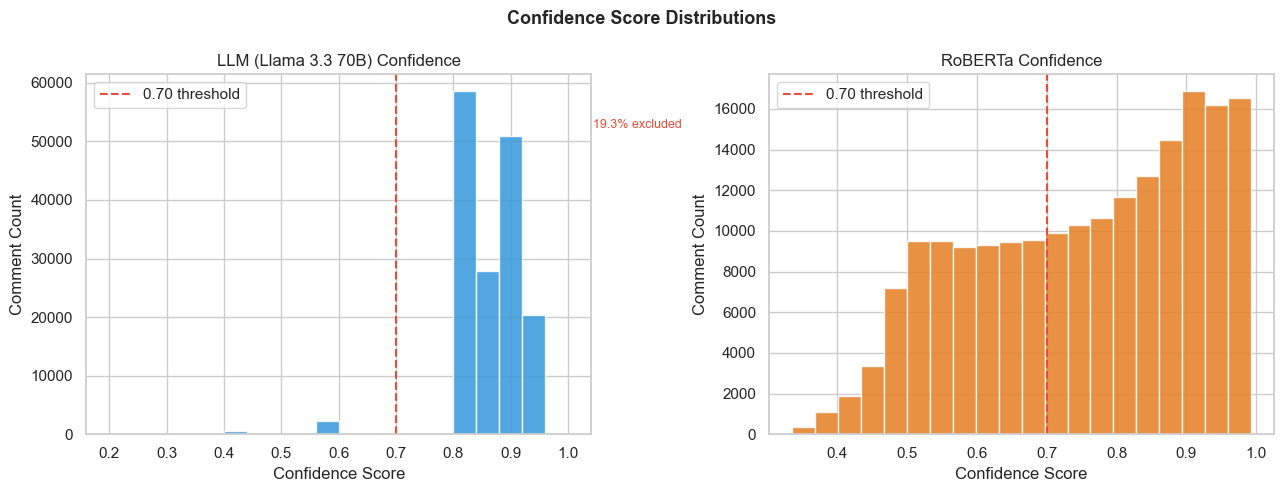

Saved → figures/12_confidence_distributions.png


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confidence Score Distributions', fontsize=13, fontweight='bold')

# LLM confidence
ax = axes[0]
ax.hist(df['confidence'], bins=20, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(0.70, color='#e74c3c', linewidth=1.5, linestyle='--', label='0.70 threshold')
ax.set_title('LLM (Llama 3.3 70B) Confidence')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Comment Count')
ax.legend()

# RoBERTa confidence
ax = axes[1]
ax.hist(roberta_df['roberta_confidence'], bins=20, color='#e67e22', edgecolor='white', alpha=0.85)
ax.axvline(0.70, color='#e74c3c', linewidth=1.5, linestyle='--', label='0.70 threshold')
low_pct = 100 * (roberta_df['roberta_confidence'] < 0.70).mean()
ax.text(0.05, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 100,
        f'{low_pct:.1f}% excluded', color='#e74c3c', fontsize=9)
ax.set_title('RoBERTa Confidence')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Comment Count')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '12_confidence_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/12_confidence_distributions.png")

Agreement Rate with LLM by RoBERTa Confidence Bin:
           Agreement Rate     N
conf_bin                       
0.70–0.80          0.7158  1446
0.80–0.90          0.8295  1982
0.90–0.95          0.9323  1566
0.95–1.00          0.9734  1539


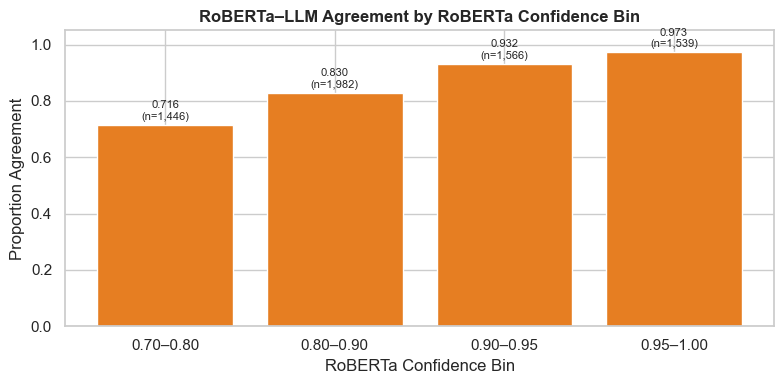

Saved → figures/13_confidence_vs_agreement.png


In [83]:
# Does higher RoBERTa confidence correlate with more agreement with LLM?

# Pull roberta_confidence into agree_df from df_compared
agree_df_conf = agree_df.merge(
    df_compared[['comment_id', 'roberta_confidence']],
    on='comment_id',
    how='left'
)

conf_bins = pd.cut(agree_df_conf['roberta_confidence'],
                   bins=[0.70, 0.80, 0.90, 0.95, 1.01],
                   labels=['0.70–0.80', '0.80–0.90', '0.90–0.95', '0.95–1.00'])
agree_df_conf['conf_bin'] = conf_bins
agree_df_conf['agree'] = (agree_df_conf['sentiment'] == agree_df_conf['roberta_sentiment']).astype(int)

conf_agree = agree_df_conf.groupby('conf_bin', observed=True)['agree'].agg(['mean', 'count'])
conf_agree.columns = ['Agreement Rate', 'N']
conf_agree['Agreement Rate'] = conf_agree['Agreement Rate'].round(4)

print("Agreement Rate with LLM by RoBERTa Confidence Bin:")
print(conf_agree.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(conf_agree.index.astype(str), conf_agree['Agreement Rate'], color='#e67e22', edgecolor='white')
ax.set_ylim(0, 1.05)
ax.set_title('RoBERTa–LLM Agreement by RoBERTa Confidence Bin', fontweight='bold')
ax.set_xlabel('RoBERTa Confidence Bin')
ax.set_ylabel('Proportion Agreement')
for bar, (_, row) in zip(ax.patches, conf_agree.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row["Agreement Rate"]:.3f}\n(n={int(row["N"]):,})',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '13_confidence_vs_agreement.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/13_confidence_vs_agreement.png")

---
## Final Summary Report

In [82]:
print("=" * 65)
print(" ARC RAIDERS SENTIMENT ANALYSIS — KEY NUMBERS FOR PAPER")
print("=" * 65)

print("\n[Section 3.1 — Dataset]")
print(f"  Total labeled comments:          {len(df):,}")
print(f"  Date range:                      {df['comment_date'].min().date()} – {df['comment_date'].max().date()}")
print(f"  Unique videos:                   {df['video_id'].nunique():,}")
print(f"  Unique commenters:               {df['author_hash'].nunique():,}")

print("\n[Section 3.5 — Confidence-Aware Filtering]")
print(f"  LLM labels with conf ≥ 0.70:     {(df['confidence'] >= 0.70).sum():,} ({100*(df['confidence'] >= 0.70).mean():.1f}%)")
print(f"  RoBERTa labels with conf ≥ 0.70: {len(roberta_hc):,} ({100*len(roberta_hc)/len(roberta_df):.1f}%)")

print("\n[Section 4.2 — Event Detection]")
print(f"  Spike days detected:             {len(spike_days)}")
print(f"  Events after clustering:         {len(events_df)}")
print(f"  Manually confirmed events:       {len(confirmed_events)}")

print("\n[Section 4.6 — RoBERTa vs LLM Agreement (High-Confidence)]")
print(f"  N (comparison pairs):            {len(agree_df):,}")
print(f"  Percent Agreement:               {pa:.3f}")
print(f"  Gwet's AC1:                      {ac1:.3f}")
print(f"  Cohen's Kappa:                   {cohen_kappa_score(llm_labels, roberta_labels):.3f}")

print("\n[Section 4.7 — Confidence]")
print(f"  LLM mean confidence:             {df['confidence'].mean():.3f}")
print(f"  LLM median confidence:           {df['confidence'].median():.3f}")
print(f"  RoBERTa mean confidence:         {roberta_df['roberta_confidence'].mean():.3f}")
print(f"  RoBERTa median confidence:       {roberta_df['roberta_confidence'].median():.3f}")

print("\n[Figures saved to figures/]")
for i, name in enumerate([
    '05_dataset_label_overview',
    '06_event_taxonomy',
    '07_temporal_sentiment_windows',
    '08_full_timeline_with_events',
    '09_category_sentiment_breakdown',
    '10_category_sentiment_timeseries',
    '11_roberta_vs_llm_confusion',
    '12_confidence_distributions',
    '13_confidence_vs_agreement',
], start=5):
    print(f"  {name}.png")

 ARC RAIDERS SENTIMENT ANALYSIS — KEY NUMBERS FOR PAPER

[Section 3.1 — Dataset]
  Total labeled comments:          160,500
  Date range:                      2021-12-10 – 2026-03-08
  Unique videos:                   905
  Unique commenters:               95,733

[Section 3.5 — Confidence-Aware Filtering]
  LLM labels with conf ≥ 0.70:     157,730 (98.3%)
  RoBERTa labels with conf ≥ 0.70: 118,403 (32.0%)

[Section 4.2 — Event Detection]
  Spike days detected:             57
  Events after clustering:         33
  Manually confirmed events:       7

[Section 4.6 — RoBERTa vs LLM Agreement (High-Confidence)]
  N (comparison pairs):            6,533
  Percent Agreement:               0.863
  Gwet's AC1:                      0.800
  Cohen's Kappa:                   0.783

[Section 4.7 — Confidence]
  LLM mean confidence:             0.855
  LLM median confidence:           0.850
  RoBERTa mean confidence:         0.753
  RoBERTa median confidence:       0.776

[Figures saved to figures/]